# Chapter 6: Optimization

### Activation Functions


#### Sigmoid

Sigmoid activations are logistic functions that are differentiable at every point, meaning we can find a
gradient at any point on a curve. If you recall, the original perceptron used a step/Heaviside function
that was not differentiable, which prevented us from optimizing networks with gradient descent via
backpropagation, as it relies on a function’s derivative. The sigmoid resolved this, allowing us to take
any real-valued number and map it as a float between 0 and 1. This made sigmoid a strong choice
for problems where predicted probabilities were required, as probabilities lie within the same range.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

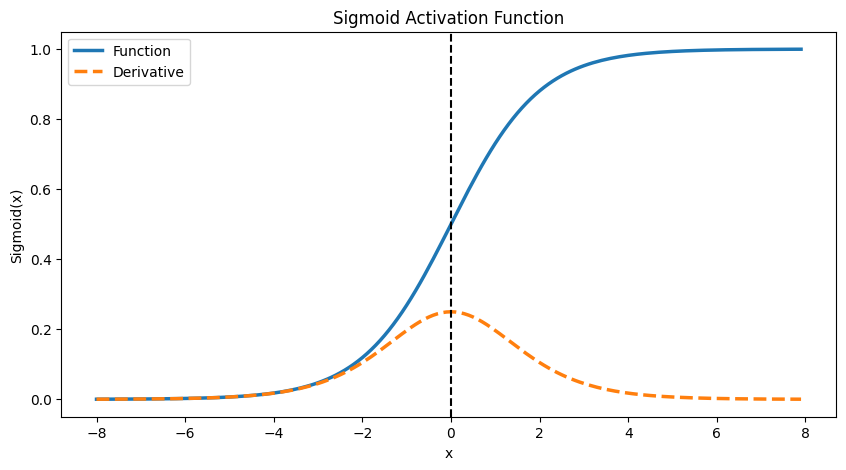

In [14]:
import Utilities.ActivationFuntionUtilities as AFU
AFU.plot_sigmoid_function()

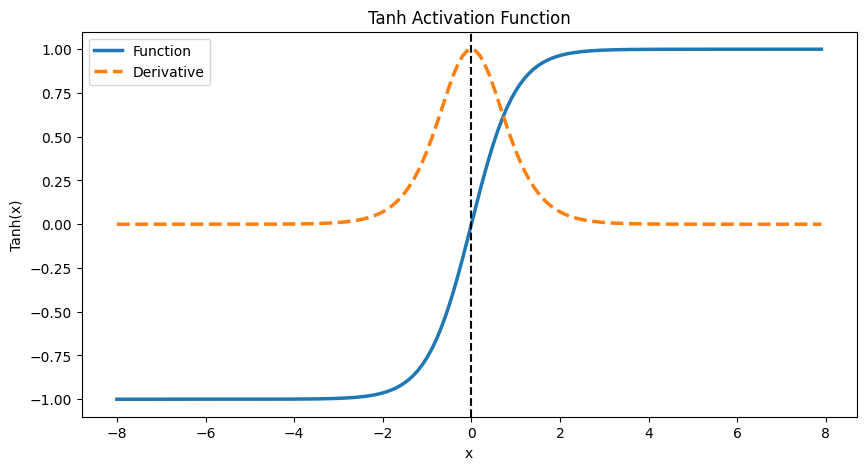

In [15]:
AFU.plot_tanh_function()

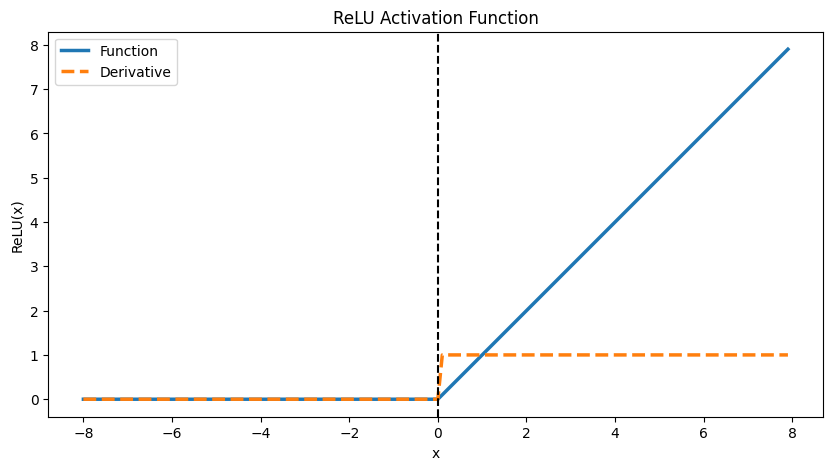

In [16]:
AFU.plot_relu_function()

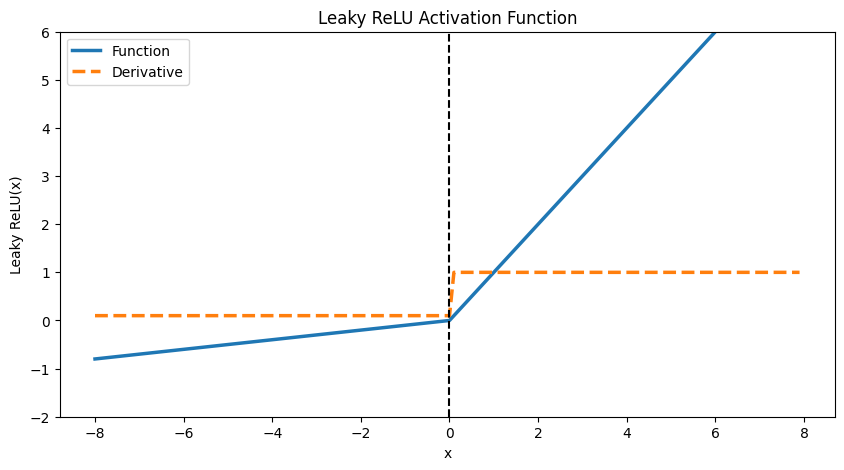

In [17]:
AFU.plot_leaky_relu_function()

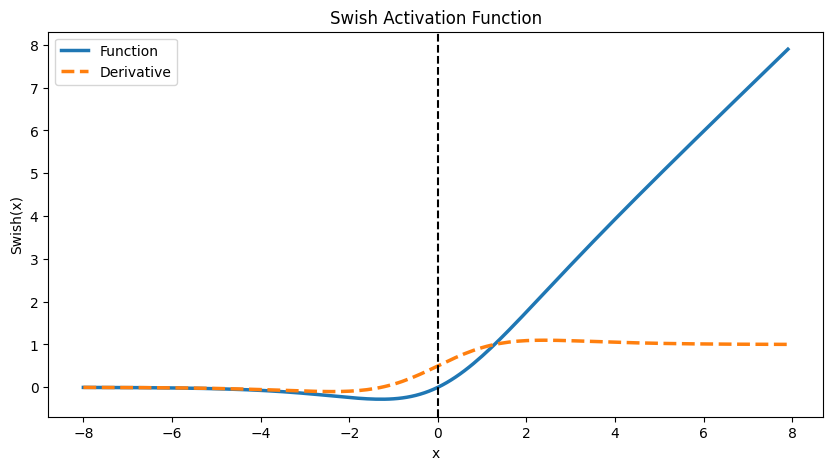

In [18]:
AFU.plot_switch_function()

### Comparing activation functions

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from Utilities.PathUtilities import get_current_working_directory

np.random.seed(42)
data = pd.read_csv(get_current_working_directory().parent / 'Data' / 'passengers.csv')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
train_size = int(len(data) * 0.6)
val_size = int(len(data) * 0.2)
train, val, test = (data[:train_size], data[train_size:train_size + val_size],
                    data[train_size + val_size:])
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

def create_time_windows(data, window_size):
    inputs = []
    targets = []
    for i in range(len(data) - window_size):
        inputs.append(data[i:i+window_size])
        targets.append(data[i+window_size])
    return np.array(inputs), np.array(targets)

In [20]:
import torch

window_size = 12

train_inputs, train_targets = create_time_windows(train_scaled, window_size)
val_inputs, val_targets = create_time_windows(val_scaled, window_size)
test_inputs, test_targets = create_time_windows(test_scaled, window_size)

x_train = torch.FloatTensor(train_inputs)
y_train = torch.FloatTensor(train_targets)

x_val = torch.FloatTensor(val_inputs)
y_val = torch.FloatTensor(val_targets)

x_test = torch.FloatTensor(test_inputs)
y_test = torch.FloatTensor(test_targets)

In [68]:
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as L
from pytorch_lightning.callbacks import EarlyStopping
import torch.nn as nn

class TimeSeriesDataModule(L.LightningDataModule):
    def __init__(self, train_data, val_data, test_data, batch_size=64):
        super().__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.test_data = test_data
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(*self.train_data)
        self.val_dataset = TensorDataset(*self.val_data)
        self.test_dataset = TensorDataset(*self.test_data)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=False)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

class ffnetwork(L.LightningModule):
    def __init__(
        self, input_dim, hidden_dim, activation_func,
        output_dim=1, learning_rate=0.0001):
        super(ffnetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.activation = activation_func
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.learning_rate = learning_rate

    def forward(self, x):
        x = x.squeeze(-1)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

class swish(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

In [22]:
input_dim = 12
hidden_dim = 50
output_dim = 1
learning_rate = 0.0001
batch_size = 64

data_module = TimeSeriesDataModule(train_data=(x_train, y_train),
 val_data=(x_val, y_val),
 test_data=(x_test, y_test),
 batch_size=batch_size)

activations = {
 'ReLU': nn.ReLU(),
 'Sigmoid': nn.Sigmoid(),
 'Tanh': nn.Tanh(),
 'LeakyReLU': nn.LeakyReLU(0.01),
 'Swish': swish()
}

In [25]:
results = {}
for name, activation_func in activations.items():
    print(f"Training with {name} activation...")
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    model = ffnetwork(input_dim, hidden_dim, activation_func, output_dim, learning_rate)

    early_stop_callback = EarlyStopping(
    monitor='val_loss', patience=10, verbose=False)
    trainer = L.Trainer(max_epochs=2000, callbacks=[early_stop_callback])
    trainer.fit(model, data_module)
    model.eval()

    last_window = x_val[-1].view(1, -1)
    recursive_preds = []

    for _ in range(len(x_test)):
        with torch.no_grad():
            pred = model(last_window)
        recursive_preds.append(pred.item())
        last_window = torch.cat((last_window[:, 1:], pred.view(1, 1)), dim=1)

    unscaled_predictions = scaler.inverse_transform(np.array(recursive_preds).reshape(-1, 1))
    results[name] = unscaled_predictions

    del model
    torch.cuda.empty_cache()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training with ReLU activation...


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ fc1        │ Linear │    650 │ train │     0 │
│ 1 │ activation │ ReLU   │      0 │ eval  │     0 │
│ 2 │ fc2        │ Linear │     51 │ train │     0 │
└───┴────────────┴────────┴────────┴───────┴───────┘

Trainable params: 701                                                                                              
Non-trainable params: 0                                                                                            
Total params: 701                                                                                                  
Total estimated model params size (MB): 0.003                                                                      
Modules in train mode: 2                                                                                           
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of 
training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

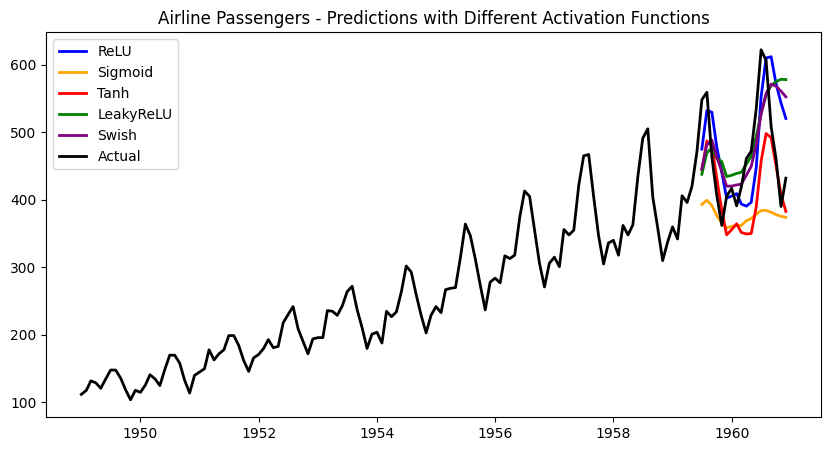

In [26]:
from matplotlib import pyplot as plt
from Utilities.ColorUtilities import custom_palette

plt.figure(figsize=(10, 5))
for idx, (name, preds) in enumerate(results.items()):
    test_index = data.index[-len(preds):]
    plt.plot(test_index, preds, label=f'{name}', color=custom_palette[idx + 1], linewidth=2.0)
plt.plot(data.index, data['passengers'], label='Actual', color=custom_palette[0], linewidth=2.0)
plt.title('Airline Passengers - Predictions with Different Activation Functions')
plt.legend()
plt.show()

Hidden Layers:

In [27]:
class ffnetwork(L.LightningModule):
    def __init__(
            self, input_dim, hidden_dim, num_layers=1, output_dim=1,
            learning_rate=0.0001, activation_func=nn.ReLU()):
        super(ffnetwork, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, output_dim))
        self.activation = activation_func
        self.learning_rate = learning_rate

    def forward(self, x):
        x = x.squeeze(-1)
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        x = self.layers[-1](x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [28]:
results = {}
hidden_layer_configs = range(1, 7)

for num_layers in hidden_layer_configs:
    print(f"Training model with {num_layers} hidden layers...")
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)

    model = ffnetwork(input_dim, hidden_dim, num_layers=num_layers,
        output_dim=output_dim, learning_rate=learning_rate)

    early_stop_callback = EarlyStopping(monitor='val_loss', patience=10, verbose=False)
    trainer = L.Trainer(max_epochs=2000, callbacks=[early_stop_callback])

    trainer.fit(model, data_module)
    model.eval()
    last_window = x_val[-1].view(1, -1)
    recursive_preds = []

    for _ in range(len(x_test)):
        with torch.no_grad():
            pred = model(last_window)
        recursive_preds.append(pred.item())
        last_window = torch.cat((last_window[:, 1:], pred.view(1, 1)), dim=1)

    unscaled_predictions = scaler.inverse_transform(np.array(recursive_preds).reshape(-1, 1))
    results[f'{num_layers} layers'] = unscaled_predictions

    del model
    torch.cuda.empty_cache()

Training model with 1 hidden layers...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layers     │ ModuleList │    701 │ train │     0 │
│ 1 │ activation │ ReLU       │      0 │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 701                                                                                              
Non-trainable params: 0                                                                                            
Total params: 701                                                                                                  
Total estimated model params size (MB): 0.003                                                                      
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of 
training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:538: Found 1 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

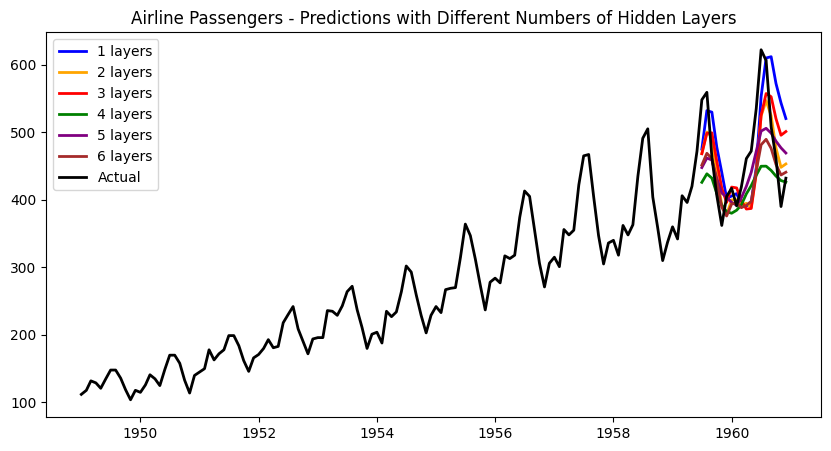

In [29]:
plt.figure(figsize=(10, 5))
for idx, (name, preds) in enumerate(results.items()):
    test_index = data.index[-len(preds):]
    plt.plot(test_index, preds, label=f'{name}',color=custom_palette[idx + 1], linewidth=2.0)

plt.plot(data.index, data['passengers'], label='Actual',color=custom_palette[0], linewidth=2.0)
plt.title('Airline Passengers - Predictions with Different Numbers of Hidden Layers')
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from Utilities.ErrorMetricsUtilities import rmse, mape, smape

def r_squared(actual, predicted, percision=8):
    residuals = actual - predicted
    ss_res = sum(residuals ** 2)
    ss_tot = sum((actual - actual.mean()) ** 2)
    return round((1 - (ss_res / ss_tot))[0], percision)

unscaled_actuals = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
errors = {'Model': [], 'MAE': [], 'MSE': [], 'RMSE': [], 'MAPE': [], 'sMAPE': [], 'R-Squared': []}
for name, preds in results.items():
    errors['Model'].append(name)
    errors['MAE'].append(mean_absolute_error(unscaled_actuals, preds))
    errors['MSE'].append(mean_squared_error(unscaled_actuals, preds))
    errors['RMSE'].append(rmse(unscaled_actuals, preds))
    errors['MAPE'].append(mape(unscaled_actuals, preds))
    errors['sMAPE'].append(smape(unscaled_actuals, preds))
    errors['R-Squared'].append(r_squared(unscaled_actuals, preds))
pd.DataFrame(errors)

,Model,MAE,MSE,RMSE,MAPE,sMAPE,R-Squared
0,1 layers,63.215017,5583.356143,74.721859,13.871361,13.239810,0.003385
1,2 layers,45.534841,2876.339877,53.631519,9.337609,9.697664,0.486581
2,3 layers,56.687415,4082.962317,63.898062,11.984527,12.024017,0.271202
3,4 layers,59.107633,6083.651230,77.997764,11.414755,12.420964,-0.085916
4,5 layers,46.014123,3555.364628,59.626878,9.261756,9.536003,0.365377
5,6 layers,50.715852,4247.169647,65.170313,9.997914,10.667872,0.241891


Loss and Optimizers

In [69]:
from lightning.pytorch.loggers import CSVLogger

class ffnetwork(L.LightningModule):
    def __init__(self, input_dim, hidden_dim, num_layers=1, output_dim=1,
        learning_rate=0.0001, dropout_rate=0.00,
        activation_func=nn.ReLU(), optimizer_name='Adam'):
        super(ffnetwork, self).__init__()
        self.layers = nn.ModuleList([nn.Linear(input_dim, hidden_dim)])
        self.dropout = nn.Dropout(dropout_rate)

        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))

        self.layers.append(nn.Linear(hidden_dim, output_dim))
        self.activation = activation_func
        self.learning_rate = learning_rate
        self.optimizer_name = optimizer_name

    def forward(self, x):
        x = x.squeeze(-1)
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
            x = self.dropout(x)
        x = self.layers[-1](x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizers = {
            'SGD': torch.optim.SGD(self.parameters(), lr=self.learning_rate),
            'Adam': torch.optim.Adam(self.parameters(), lr=self.learning_rate),
            'Adadelta': torch.optim.Adadelta(self.parameters(), lr=self.learning_rate),
            'RMSprop': torch.optim.RMSprop(self.parameters(), lr=self.learning_rate),
            'Adagrad': torch.optim.Adagrad(self.parameters(), lr=self.learning_rate),
        }
        if self.optimizer_name in optimizers:
            return optimizers[self.optimizer_name]
        else:
            raise ValueError(f"Optimizer '{self.optimizer_name}' not recognized.")

In [70]:
# List of optimiser algorithms
optimizers = ['SGD', 'Adam', 'Adadelta', 'RMSprop', 'Adagrad']
log_base = get_current_working_directory() / "lightning_logs"


results = {}
for optimizer_name in optimizers:
    print(f"Training with {optimizer_name} optimizer...")
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    model = ffnetwork(input_dim, hidden_dim, num_layers=2, output_dim=output_dim,
        learning_rate=0.001, optimizer_name=optimizer_name)

    early_stop_callback = EarlyStopping(monitor='val_loss',patience=10,verbose=False,mode='min')

    # Dictionary for logs to be saved
    log_dir = f'lightning_logs/{optimizer_name}'
    logger = CSVLogger("lightning_logs", name=optimizer_name)

    # Early stopping
    trainer = L.Trainer(max_epochs=2000, default_root_dir=log_dir,callbacks=[early_stop_callback], logger=logger) # CSV logging of training

    # Train model
    trainer.fit(model, data_module)

    # Evaluate model with test data and store predictions for plotting
    model.eval()
    last_window = x_val[-1].view(1, -1)
    recursive_preds = []

    for _ in range(len(x_test)):
        with torch.no_grad():
            pred = model(last_window)
        recursive_preds.append(pred.item())
        last_window = torch.cat((last_window[:, 1:], pred.view(1, 1)), dim=1)

    unscaled_predictions = scaler.inverse_transform(
        np.array(recursive_preds).reshape(-1, 1))
    results[optimizer_name] = unscaled_predictions

    del model
    torch.cuda.empty_cache()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training with SGD optimizer...


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layers     │ ModuleList │  3.3 K │ train │     0 │
│ 1 │ dropout    │ Dropout    │      0 │ train │     0 │
│ 2 │ activation │ ReLU       │      0 │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 K                                                                                                
Total estimated model params size (MB): 0.013                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of 
training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:538: Found 1 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=2000` reached.


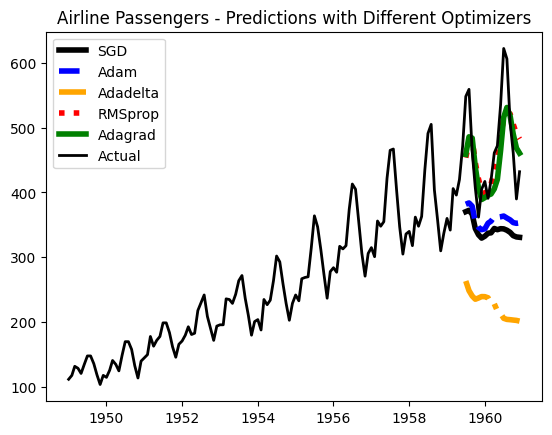

In [45]:
import itertools
line_styles = ['-', '--', '-.', ':']

style_cycle = itertools.cycle(line_styles)
colour_cycle = itertools.cycle(custom_palette)

for name, preds in results.items():
    test_index = data.index[-len(preds):]
    plt.plot(test_index, preds, label=f'{name}',
             color=next(colour_cycle), linestyle=next(style_cycle), linewidth=4)
plt.plot(data.index, data['passengers'], label='Actual',
         color='black', linewidth=2.0)
plt.title('Airline Passengers - Predictions with Different Optimizers')
plt.legend()
plt.show()

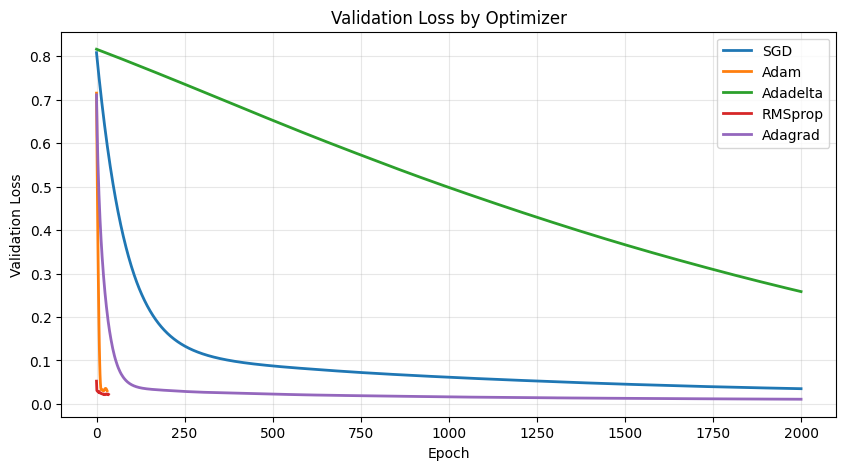

In [46]:
plt.figure(figsize=(10, 5))
for opt in optimizers:
    metrics_path = log_base / opt / "version_0" / "metrics.csv"
    if metrics_path.exists():
        df_log = pd.read_csv(metrics_path)
        val_df = df_log[df_log["val_loss"].notna()].copy()
        plt.plot(val_df["epoch"], val_df["val_loss"], label=opt, linewidth=2)
plt.title("Validation Loss by Optimizer")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Learning rate scheduling
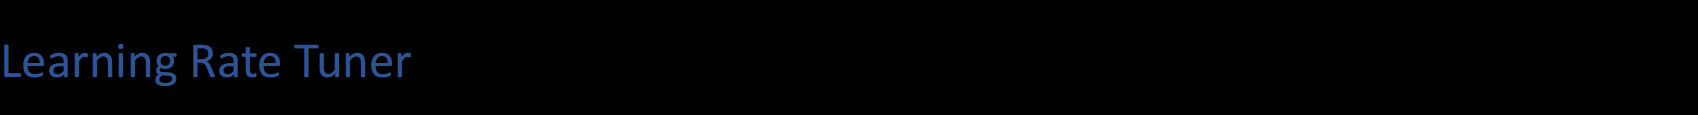

In [47]:
def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)
    return {
     'optimizer': optimizer,
     'lr_scheduler':
        {
            'scheduler': scheduler,
            'monitor': 'val_loss'
        }
    }

In [74]:
model = ffnetwork(input_dim, hidden_dim, num_layers=2, output_dim=output_dim,
        learning_rate=0.001, optimizer_name='Adam')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers whic

Suggested LR: 2.2908676527677735e-07


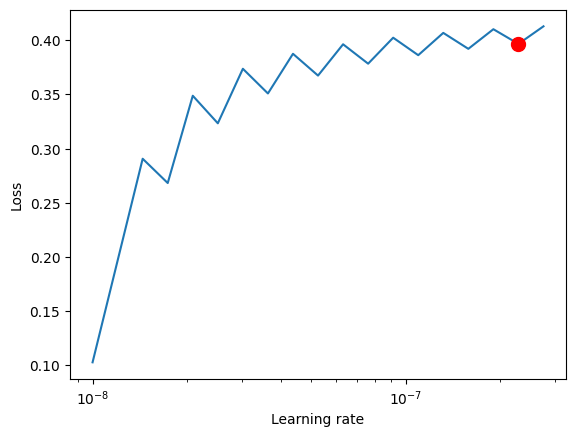

In [75]:
#import lightning as L
from pytorch_lightning.tuner import Tuner

trainer = L.Trainer(max_epochs=100)
tuner = Tuner(trainer)

# runs LR range test and updates model.learning_rate
lr_finder = tuner.lr_find(model, datamodule=data_module)

# plot loss curve
fig = lr_finder.plot(suggest=True)
fig.show()

# suggested LR
print(f"Suggested LR: {lr_finder.suggestion()}")

In [76]:
class ffnetwork(L.LightningModule):
 def __init__(self, input_dim, hidden_dim, num_layers=1, output_dim=1,
 learning_rate=0.0001, dropout_rate=0.5, activation_func=nn.ReLU()
 ):
    super(ffnetwork, self).__init__()
    self.layers = nn.ModuleList([nn.Linear(input_dim, hidden_dim)])
    self.dropout = nn.Dropout(dropout_rate)

    for _ in range(num_layers - 1):
        self.layers.append(nn.Linear(hidden_dim, hidden_dim))

    self.layers.append(nn.Linear(hidden_dim, output_dim))
    self.activation = activation_func
    self.learning_rate = learning_rate

def forward(self, x):
    x = x.squeeze(-1)
    for i in range(len(self.layers) - 1):
        x = self.activation(self.layers[i](x))
        x = self.dropout(x) # Apply dropout after each hidden layer
    x = self.layers[-1](x)
    return x

def training_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self.forward(x)
    loss = nn.functional.mse_loss(y_hat, y)
    self.log('train_loss', loss)
    return loss

def validation_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self.forward(x)
    loss = nn.functional.mse_loss(y_hat, y)
    self.log('val_loss', loss)

def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
    return optimizer

### Hyperparameter tuning

In [77]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3)
    hidden_dim = trial.suggest_categorical('hidden_dim', [6, 10, 20, 40])
    num_layers = trial.suggest_int('num_layers', 1, 6)
    model = ffnetwork(
    input_dim, hidden_dim, num_layers=num_layers, output_dim=output_dim,
    learning_rate=learning_rate, dropout_rate=dropout_rate
    )

    early_stop_callback = EarlyStopping(
    monitor='val_loss', patience=10,
    verbose=False, mode='min'
    )

    trainer = L.Trainer(
    max_epochs=100, callbacks=[early_stop_callback],
    logger=False, enable_checkpointing=False)

    trainer.fit(model, data_module)
    model.eval()
    last_window = x_val[-1].view(1, -1)
    recursive_preds = []

    for _ in range(len(x_test)):
        with torch.no_grad():
            pred = model(last_window)
        recursive_preds.append(pred.item())
        last_window = torch.cat((last_window[:, 1:], pred.view(1, 1)), dim=1)

    recursive_preds = np.array(recursive_preds).reshape(-1, 1)
    y_test_np = y_test.numpy().reshape(-1, 1)
    mse_val = np.mean((recursive_preds - y_test_np) ** 2)
    trial.set_user_attr("MSE", mse_val)
    return mse_val

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# Extract best results
print(f"Best hyperparameters: {study.best_params}")
print(f"Best MSE: {study.best_value:.4f}")

[I 2026-09-23 11:37:19,986] A new study created in memory with name: no-name-7f821ab6-5202-42f4-acc5-37a23091974f
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
[W 2026-09-23 11:37:21,205] Trial 0 failed with parameters: {'learning_rate': 0.0009605266533346041, 'dropout_rate': 0.088754512747802, 'hidden_dim': 10, 'num_layers': 5} because of the following error: MisconfigurationException('No `training_step()` method defined. Lightning `Trainer` expects as minimum a `training_step()`, `train_dataloader()` and `configure_optimizers()` to be defined.').
Traceback (most recent call last):
  File "C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(

MisconfigurationException: No `training_step()` method defined. Lightning `Trainer` expects as minimum a `training_step()`, `train_dataloader()` and `configure_optimizers()` to be defined.